# 합성함수

두 함수 $f$, $g$에 대해 **합성함수**는

$$
(f \circ g)(x) = f\big(g(x)\big)
$$

먼저 $g$를 적용한 뒤, 그 결과에 $f$를 적용한다.  
일반적으로 $f\circ g \neq g\circ f$이다.


## 1. 정의와 계산


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

sp.init_printing()
x = sp.symbols('x')

f_expr = 2*x + 1      # f(x) = 2x+1
g_expr = x**2 - 3     # g(x) = x^2-3

# 수동 합성: f(g(x)), g(f(x))
fog = f_expr.subs(x, g_expr).expand()
gof = g_expr.subs(x, f_expr).expand()

print("(f∘g)(x) = f(g(x)):")
display(fog)
print("(g∘f)(x) = g(f(x)):")
display(gof)
print("같음?:", sp.simplify(fog - gof) == 0)


(f∘g)(x) = f(g(x)):


(g∘f)(x) = g(f(x)):


같음?: False


**expr.subs(x, other)**: <br>
=> $x$ 자리에 다른 식을 넣어 합성

**.expand() / sp.simplify()**: <br>
=> 전개 · 간단화


## 2. sympy.compose


In [7]:
# sp.compose(f, g) ≡ f(g(x))
fog2 = sp.compose(f_expr, g_expr)
print("sp.compose(f, g):")
display(fog2.expand())
print("수동 합성과 일치?:", sp.expand(fog2) == fog)


sp.compose(f, g):


수동 합성과 일치?: True


**sp.compose(f, g)**: <br>
=> $f(g(x))$ (인자의 순서가 중요)


## 3. 결합법칙

$$
(f \circ g) \circ h = f \circ (g \circ h)
$$

합성은 결합법칙은 성립하지만, 교환법칙은 일반적으로 성립하지 않음.


In [8]:
h_expr = 3*x - 1

left = sp.compose(sp.compose(f_expr, g_expr), h_expr).expand()
right = sp.compose(f_expr, sp.compose(g_expr, h_expr)).expand()

print("(f∘g)∘h:")
display(left)
print("f∘(g∘h):")
display(right)
print("결합법칙 성립?:", left == right)


(f∘g)∘h:


f∘(g∘h):


결합법칙 성립?: True


## 4. 정의역 주의

$(f\circ g)(x)$가 정의되려면

1. $x$가 $g$의 정의역에 있고
2. $g(x)$가 $f$의 정의역에 있어야함 

예: $f(t)=\sqrt{t}$, $g(x)=x-2$이면 $(f\circ g)(x)=\sqrt{x-2}$ → **정의역 $x\ge 2$**.


합성:


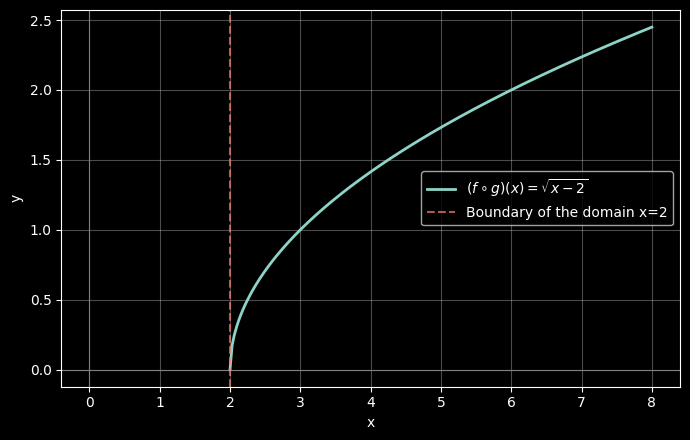

In [9]:
f_sqrt = sp.sqrt(x)
g_shift = x - 2
fog_sqrt = sp.compose(f_sqrt, g_shift)
print("합성:")
display(fog_sqrt)

# 수치 그래프: 정의역 x >= 2
xs = np.linspace(2, 8, 200)
ys = np.sqrt(xs - 2)

plt.figure(figsize=(7, 4.5))
plt.axhline(0, color='gray', lw=0.8)
plt.axvline(0, color='gray', lw=0.8)
plt.plot(xs, ys, label=r'$(f\circ g)(x)=\sqrt{x-2}$', lw=2)
plt.axvline(2, color='C3', ls='--', alpha=0.7, label='Boundary of the domain x=2')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
